In [10]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [11]:
ds1 = xr.open_dataset('/glade/work/netige/Data/VIKING/viking_obp_ssh_msc_residuals.nc')
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

In [12]:
bathy = xr.open_dataset('/glade/work/netige/Data/Bathymetry/GLO-MFC_001_030_mask_bathy.nc')

In [13]:
data32 = bathy["deptho"].astype("float32")            # meters, positive down
data32 = data32.where(np.isfinite(data32)) 

data32 = data32.sel(
    latitude=slice(-33.5, 65),
    longitude=slice(-98, 20)
)
b_lat = data32["latitude"]; b_lon = data32["longitude"]; b_field = data32


In [14]:
with ProgressBar():

# --- inputs ---
    raw_obp = viking_ds["obp_rm_dt"]          # (time, lat, lon)
    msc_obp = ds1["viking_obp_MSC"]           # (month, lat, lon)
    res_obp = ds1["viking_obp_res"]           # (time, lat, lon)

# --- compute std maps ---
    std_raw = raw_obp.std(dim="time", skipna=True).compute()
    std_msc = msc_obp.std(dim="month", skipna=True).compute()
    std_res = res_obp.std(dim="time", skipna=True).compute()

# Use a common color scale across panels (optional but recommended)
    vmin = float(xr.concat([std_raw, std_msc, std_res], dim="z").min(skipna=True))
    vmax = float(xr.concat([std_raw, std_msc, std_res], dim="z").max(skipna=True))


### Coarsen data to 3-deg and re-do stds

In [15]:
import numpy as np
import xarray as xr
from typing import Optional, Sequence, Union

import numpy as np
import xarray as xr
import dask

from typing import Union, Optional, Sequence, Dict

def bin_average_ll_true2d(
    da: xr.DataArray,
    *,
    res: float = 1.0,
    lat_name: str = "lat",
    lon_name: str = "lon",
    prechunk=None,
    postchunk=None,
) -> xr.DataArray:

    lat_vals = da[lat_name].values
    lon_vals = da[lon_name].values
    lat_min, lat_max = float(np.nanmin(lat_vals)), float(np.nanmax(lat_vals))
    lon_min, lon_max = float(np.nanmin(lon_vals)), float(np.nanmax(lon_vals))

    def make_bins(vmin, vmax, step):
        start = np.floor(vmin / step) * step
        stop  = np.ceil (vmax / step) * step
        edges = np.arange(start, stop + step, step, dtype=float)
        labels = (edges[:-1] + edges[1:]) / 2.0
        return edges, labels

    lat_bins, lat_labels = make_bins(lat_min, lat_max, res)
    lon_bins, lon_labels = make_bins(lon_min, lon_max, res)
    nlon = len(lon_labels)

    if prechunk is not None:
        da = da.chunk(prechunk)
    elif "time" in da.dims:
        da = da.chunk({"time": -1})

    # 1D bin indices on each axis
    ilat = xr.DataArray(
        np.digitize(da[lat_name].values, lat_bins) - 1,
        dims=(lat_name,),
        coords={lat_name: da[lat_name]},
    )
    ilon = xr.DataArray(
        np.digitize(da[lon_name].values, lon_bins) - 1,
        dims=(lon_name,),
        coords={lon_name: da[lon_name]},
    )

    # broadcast to 2D bin indices
    ilat2d, ilon2d = xr.broadcast(ilat, ilon)

    valid = (
        (ilat2d >= 0) & (ilat2d < len(lat_labels)) &
        (ilon2d >= 0) & (ilon2d < len(lon_labels))
    )

    gid2d = (ilat2d * nlon + ilon2d).where(valid)

    # stack spatial dims -> points, drop invalid gid points
    da2 = da.assign_coords(gid=gid2d)
    s = da2.stack(points=(lat_name, lon_name))
    s = s.where(np.isfinite(s["gid"]), drop=True)

    # group mean across ALL points in each (ilat, ilon) bin (true 2D)
    out = s.groupby("gid").mean("points", skipna=True)

    # attach ilat/ilon as coords *along gid* (this is allowed)
    gid_vals = out["gid"].values.astype(np.int64)
    out = out.assign_coords(
        ilat=("gid", (gid_vals // nlon).astype(np.int64)),
        ilon=("gid", (gid_vals %  nlon).astype(np.int64)),
    )

    # pivot gid -> (ilat, ilon) -> (lat, lon)
    out2 = (
        out.set_index(gid=["ilat", "ilon"])
           .unstack("gid")
           .rename({"ilat": "lat", "ilon": "lon"})
    )

    # now safely assign actual coordinate values for the bin centers
    out2 = out2.assign_coords(
        lat=("lat", lat_labels),
        lon=("lon", lon_labels),
    )

    if postchunk is not None:
        out2 = out2.chunk(postchunk)

    return out2

def remove_seasonal_cycle(ds, time_dim="time", groupby="time.month"):
    """
    Remove the seasonal mean cycle from an xarray dataset.

    Parameters:
    ds (xr.Dataset or xr.DataArray): Input dataset or data array.
    time_dim (str): Name of the time dimension.
    groupby (str): Grouping method, default is 'time.month' (monthly climatology).

    Returns:
    xr.Dataset or xr.DataArray: Dataset or data array with the seasonal cycle removed.
    """
    climatology = ds.groupby(groupby).mean(dim=time_dim)
    return climatology, ds.groupby(groupby) - climatology

In [16]:
with ProgressBar():
    obp_3deg = bin_average_ll_true2d(
            viking_ds["obp_rm_dt"]  ,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

[########################################] | 100% Completed | 13.03 s


In [17]:
from dask.diagnostics import ProgressBar
import dask

# Rechunk to reduce task overhead
obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 34, "lon": 40})  # single spatial chunk

# Or, if you prefer a couple chunks:
# obp_3deg_rc = obp_3deg.chunk({"time": -1, "lat": 17, "lon": 20})

msc, res = remove_seasonal_cycle(obp_3deg_rc)

# Persist (or compute) both together
with ProgressBar():
    viking_obp_MSC_3deg, viking_obp_res_3deg = dask.persist(msc, res)


[########################################] | 100% Completed | 222.77 ms


In [18]:
# --- inputs ---
raw_obp_3deg = obp_3deg          # (time, lat, lon)
msc_obp_3deg = viking_obp_MSC_3deg           # (month, lat, lon)
res_obp_3deg = viking_obp_res_3deg           # (time, lat, lon)

# --- compute std maps ---
with ProgressBar():
    std_raw_3deg = raw_obp_3deg.std(dim="time", skipna=True).compute()
    std_msc_3deg = msc_obp_3deg.std(dim="month", skipna=True).compute()
    std_res_3deg = res_obp_3deg.std(dim="time", skipna=True).compute()


[########################################] | 100% Completed | 117.99 ms
[########################################] | 100% Completed | 106.30 ms
[########################################] | 100% Completed | 130.31 ms


In [19]:
data_lr = std_raw_3deg  # (lat, lon) from bin_average_ll_true2d

lat_c = data_lr["lat"].values   # centers, e.g. [..., -7.5, -4.5, -1.5, ...]
lon_c = data_lr["lon"].values   # centers, e.g. [..., -46.5, -43.5, -40.5, ...]

dlat = float(lat_c[1] - lat_c[0])   # should be ~3.0
dlon = float(lon_c[1] - lon_c[0])   # should be ~3.0

import numpy as np

# latitude edges (length Nlat+1)
lat_edges = np.empty(lat_c.size + 1, dtype=float)
lat_edges[1:-1] = 0.5 * (lat_c[:-1] + lat_c[1:])
lat_edges[0]    = lat_c[0]  - 0.5 * dlat
lat_edges[-1]   = lat_c[-1] + 0.5 * dlat

# longitude edges (length Nlon+1)
lon_edges = np.empty(lon_c.size + 1, dtype=float)
lon_edges[1:-1] = 0.5 * (lon_c[:-1] + lon_c[1:])
lon_edges[0]    = lon_c[0]  - 0.5 * dlon
lon_edges[-1]   = lon_c[-1] + 0.5 * dlon



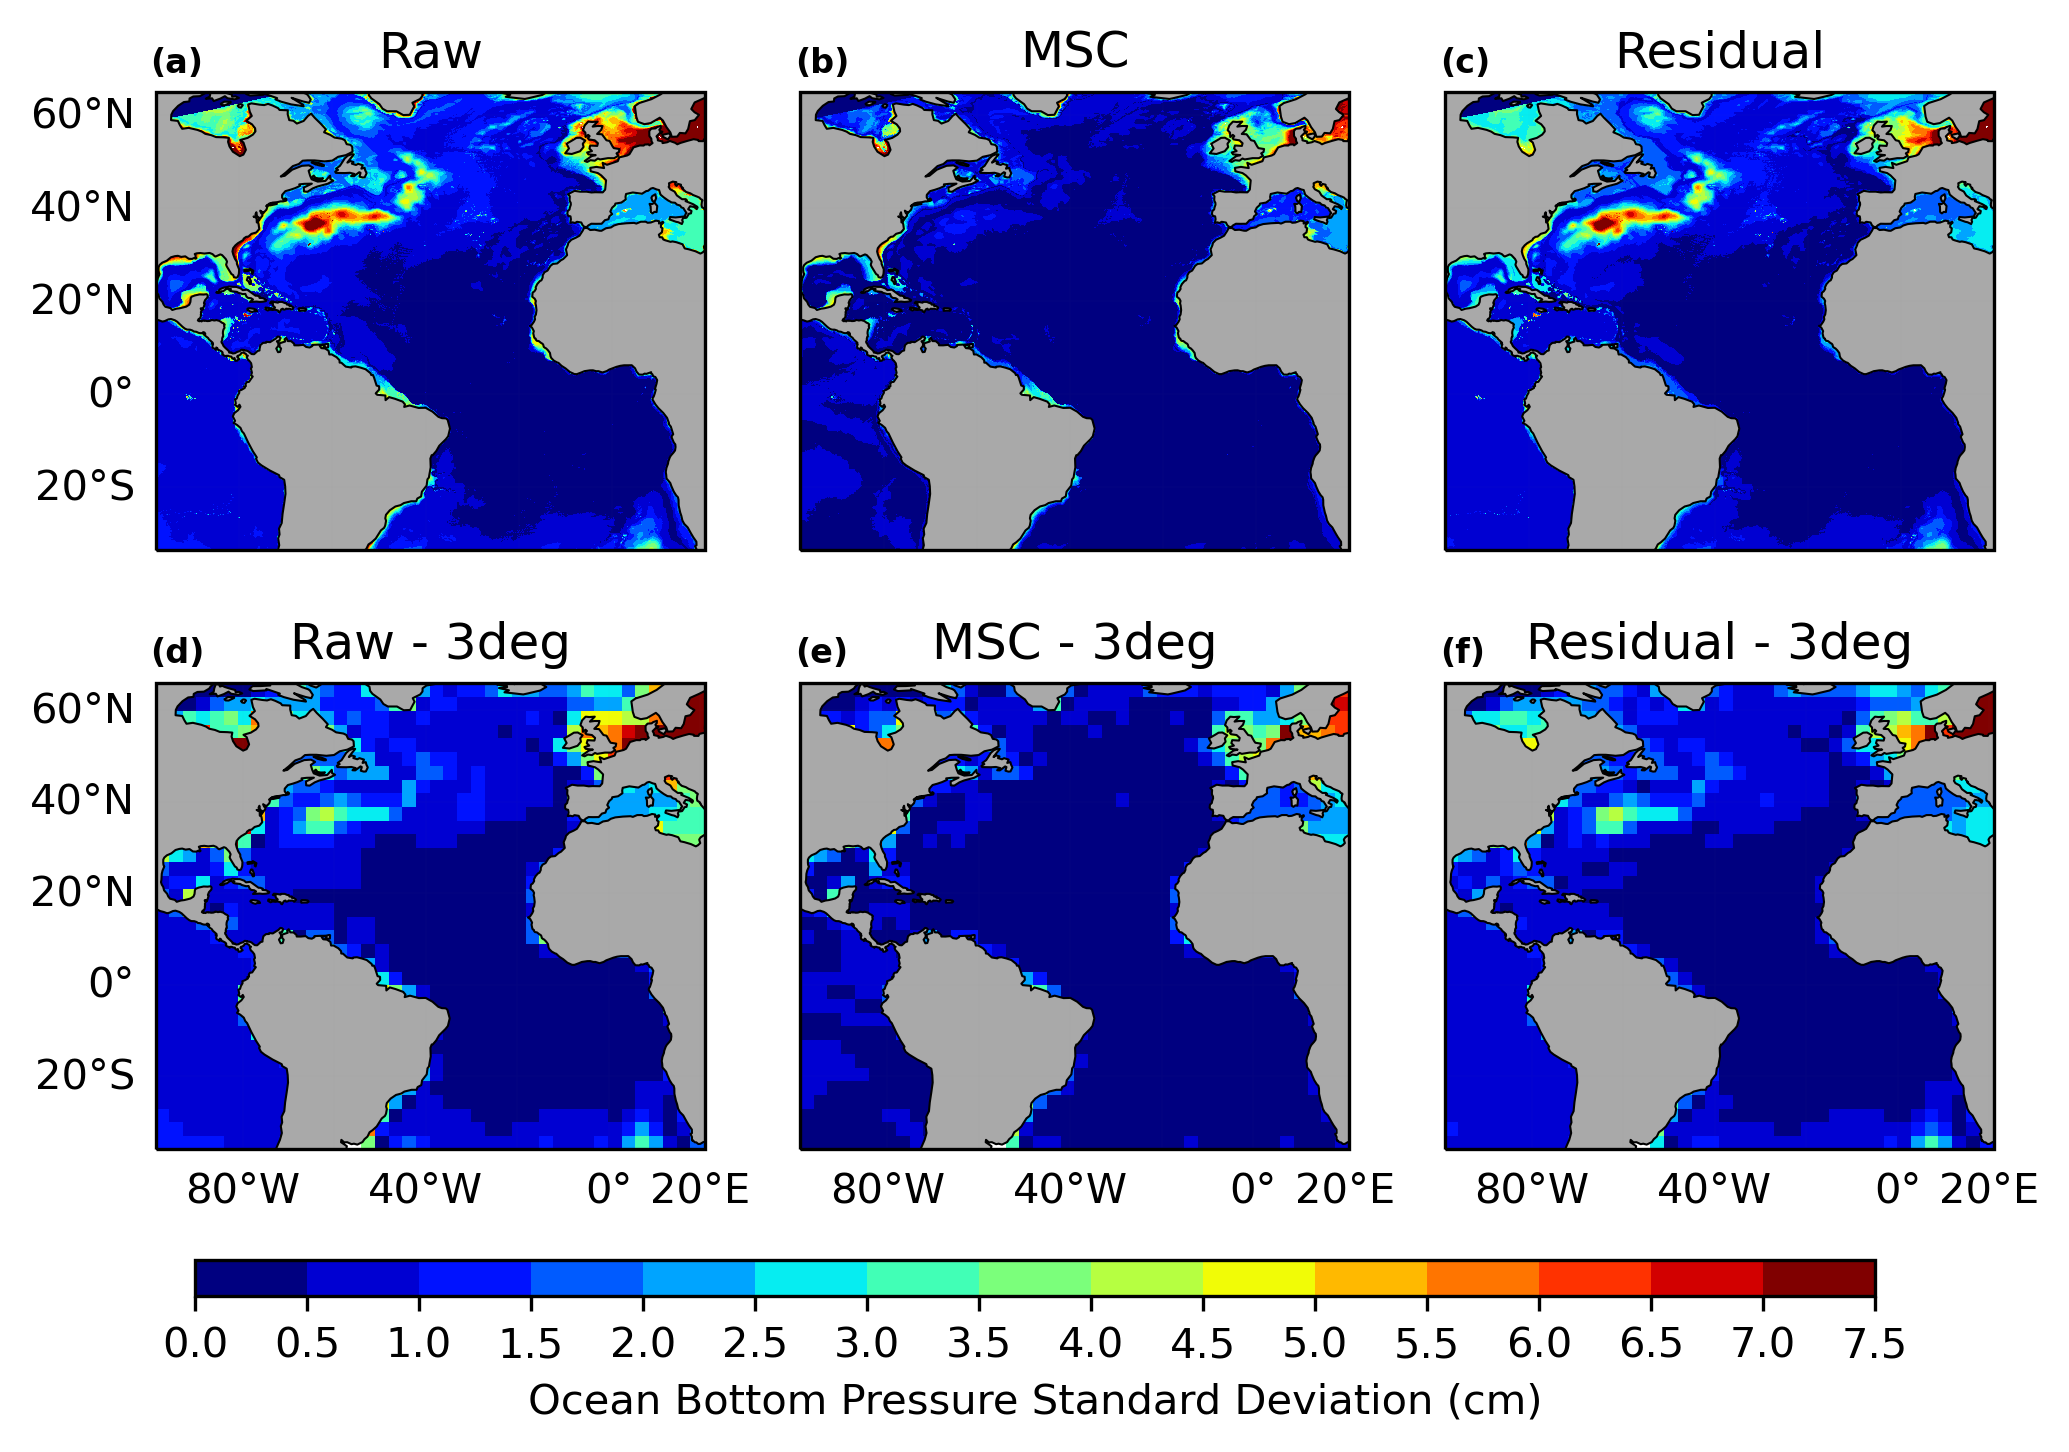

In [21]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    if i in (0, 1, 2):
        pc = ax.pcolormesh(data.lon, 
                           data.lat, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    else:
        pc = ax.pcolormesh(lon_edges, 
                           lat_edges, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("VIKING_OBP_Stds_raw_MSC_res_TM2.png", dpi=500, bbox_inches='tight')

plt.show()


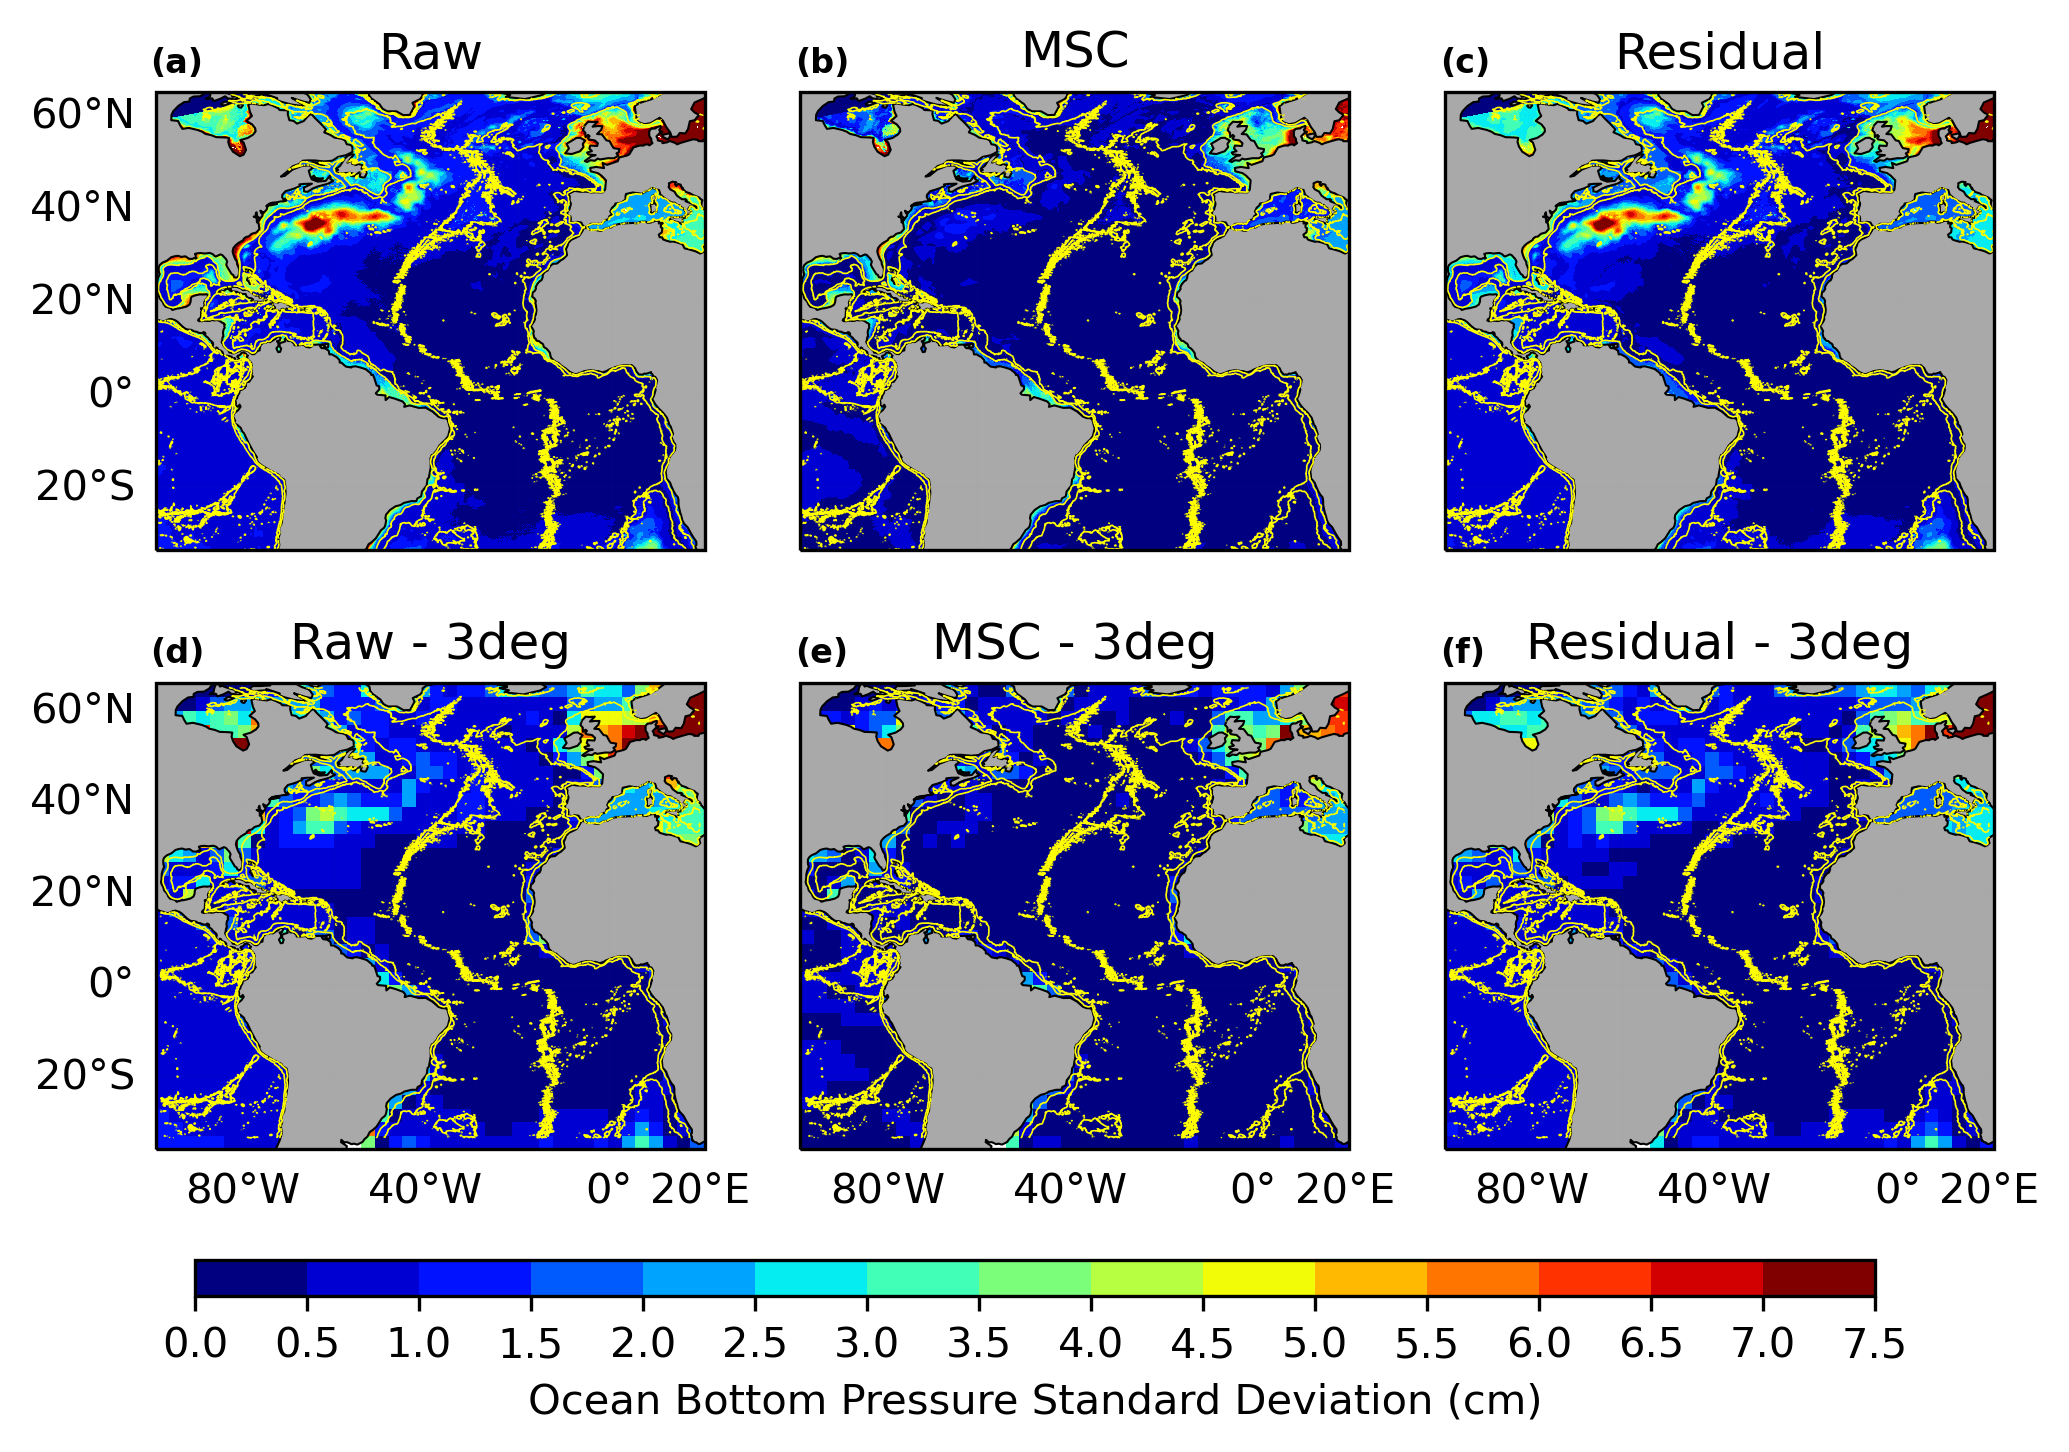

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_raw,
    std_msc,
    std_res,
    std_raw_3deg,
    std_msc_3deg,
    std_res_3deg
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual",
    "Raw - 3deg",
    "MSC - 3deg",
    "Residual - 3deg"
]

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 8, 0.5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    if i in (0, 1, 2):
        pc = ax.pcolormesh(data.lon, 
                           data.lat, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    else:
        pc = ax.pcolormesh(lon_edges, 
                           lat_edges, 
                           data,
                           transform=ccrs.PlateCarree(), 
                           cmap=cmap,
                           norm=norm)
    levels = [200, 3000]
    cs = ax.contour(
        b_lon, b_lat, b_field,
        levels=levels, colors="yellow", linewidths=0.4,
        transform=ccrs.PlateCarree()
    )
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 3
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Ocean Bottom Pressure Standard Deviation (cm)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("VIKING_OBP_Stds_raw_MSC_res_bathy_TM2.png", dpi=500, bbox_inches='tight')

plt.show()


#### Convert hi-res std. to compatible low-res grid to compute std differences.

In [23]:
with ProgressBar():
    std_raw_coarse = bin_average_ll_true2d(
            std_raw,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

In [24]:
with ProgressBar():
    std_msc_coarse = bin_average_ll_true2d(
            std_msc,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

In [25]:
with ProgressBar():
    std_res_coarse = bin_average_ll_true2d(
            std_res,
            res=3,
            lat_name="lat", lon_name="lon",
            # KEY CHANGE: small time chunks; single spatial chunks
            #prechunk={"time": -1, "lat": -1, "lon": -1},
            # Optional: reshape the OUTPUT into nicer worker-sized tiles
            #postchunk={"time": 12, "lat": 256, "lon": 256},
            #persist_cut=True,   # if your function supports this, it helps
        ).persist()

In [26]:
std_dif_raw_norm = (std_raw_coarse - std_raw_3deg)/std_raw_coarse
std_dif_msc_norm = (std_msc_coarse - std_msc_3deg)/std_msc_coarse
std_dif_res_norm = (std_res_coarse - std_res_3deg)/std_res_coarse

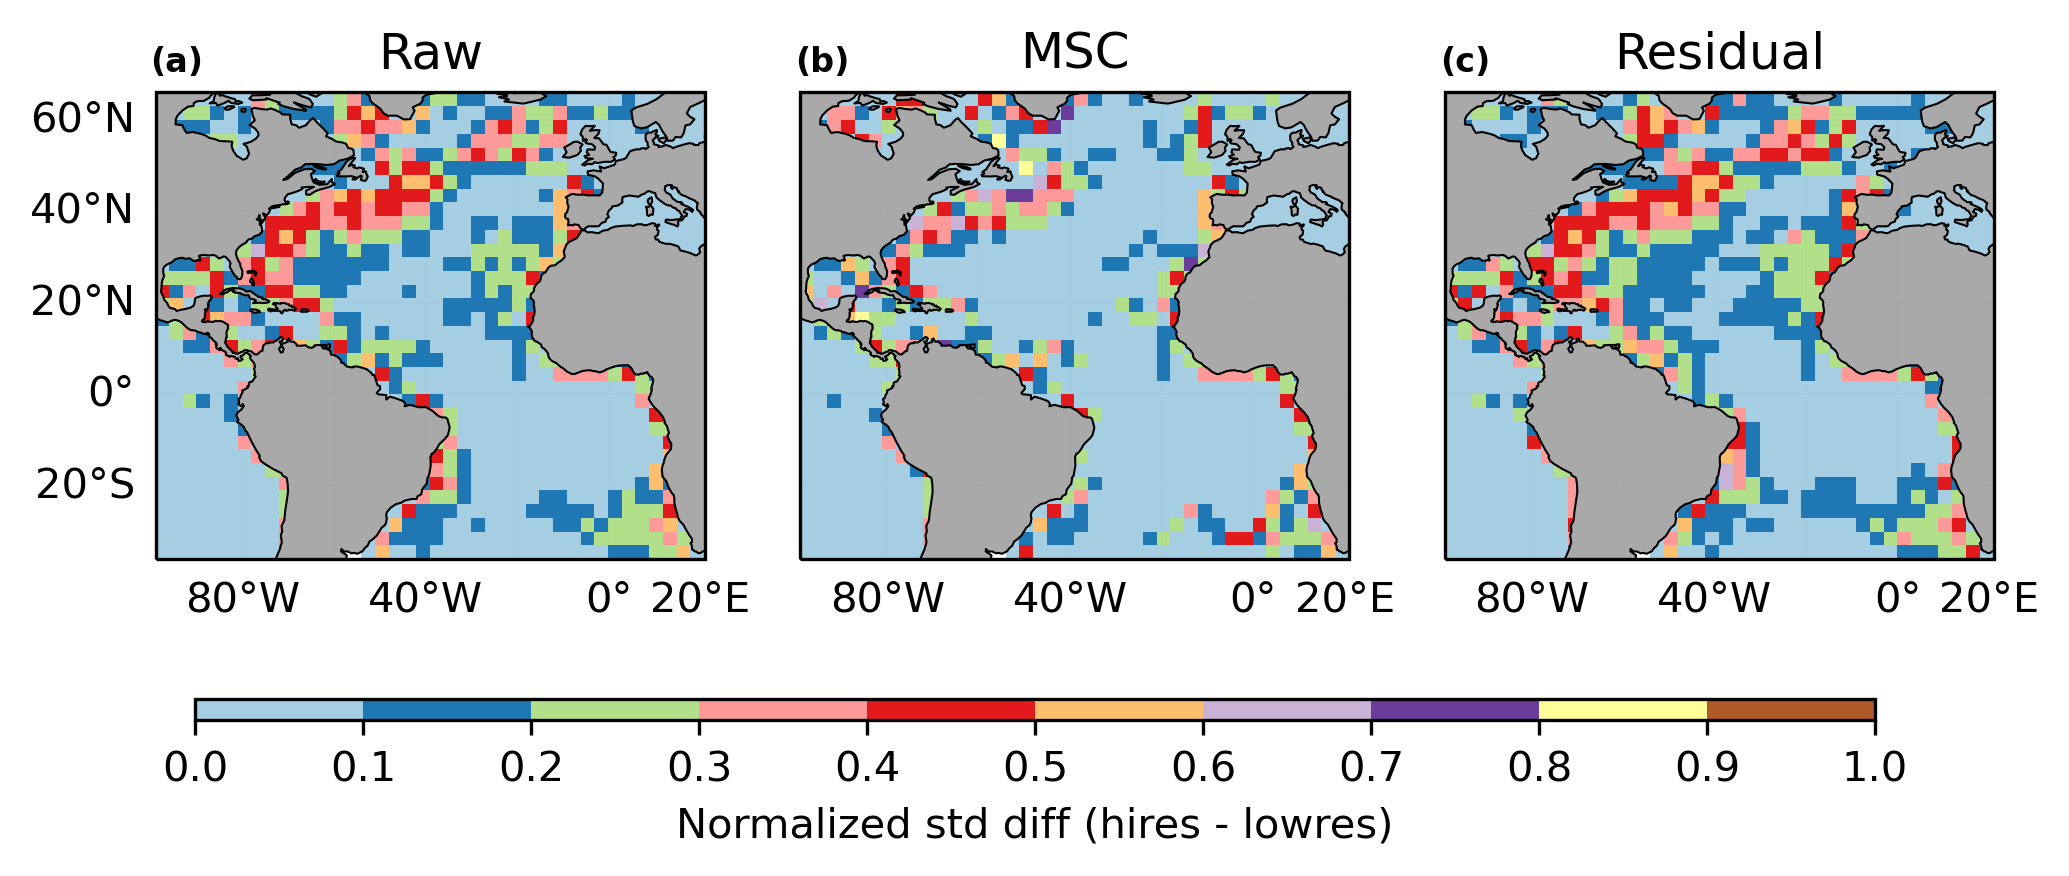

In [29]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_dif_raw_norm,
    std_dif_msc_norm,
    std_dif_res_norm
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual"
]

labels = ['(a)', '(b)', '(c)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 1.1, 0.1)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("Paired", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(7, 2.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(lon_edges, 
                       lat_edges, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)
    
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 0
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Normalized std diff (hires - lowres)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("VIKING_OBP_Std_dif_TM2.png", dpi=500, bbox_inches='tight')

plt.show()


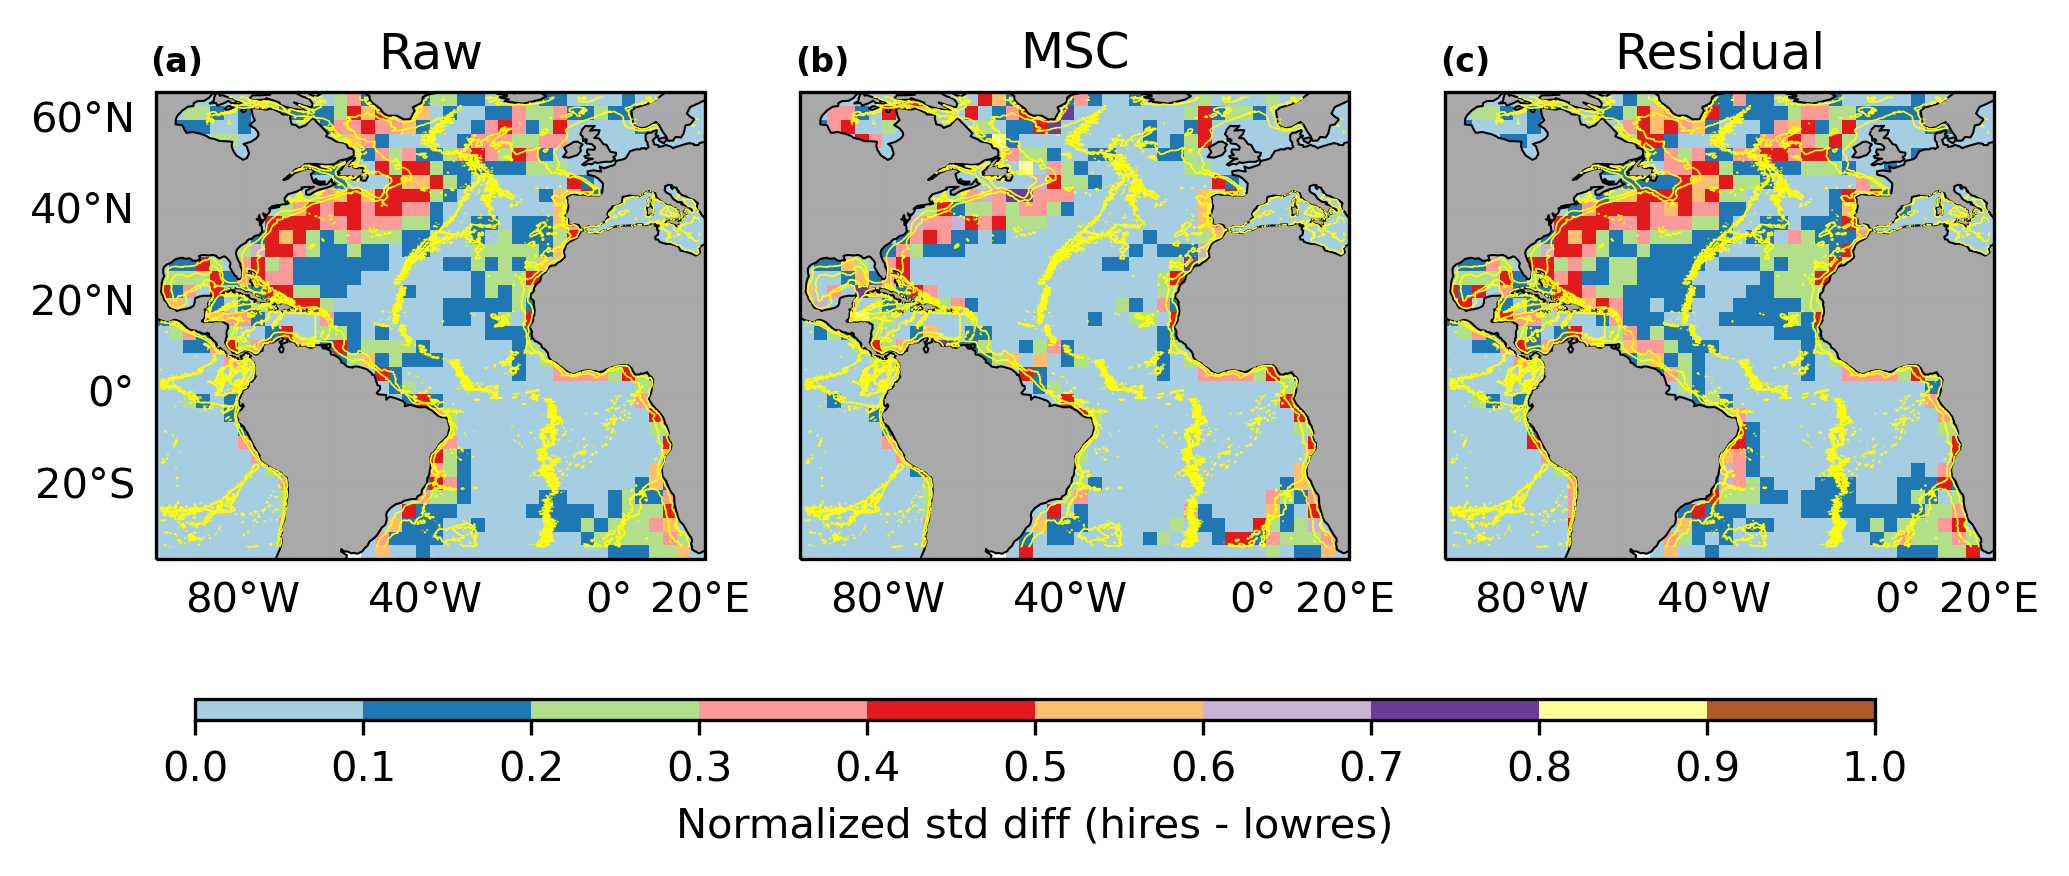

In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define the datasets and titles
data_list = [
    std_dif_raw_norm,
    std_dif_msc_norm,
    std_dif_res_norm
]

title_list = [
    "Raw", 
    "MSC", 
    "Residual"
]

labels = ['(a)', '(b)', '(c)']

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 1.1, 0.1)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("Paired", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(7, 2.8), dpi=300, 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

for i, (ax, data, title) in enumerate(zip(axes.flat, data_list, title_list)):
    pc = ax.pcolormesh(lon_edges, 
                       lat_edges, 
                       data,
                       transform=ccrs.PlateCarree(), 
                       cmap=cmap,
                       norm=norm)

    levels = [200, 3000]
    cs = ax.contour(
        b_lon, b_lat, b_field,
        levels=levels, colors="yellow", linewidths=0.4,
        transform=ccrs.PlateCarree()
    )
    
    #ax.set_global() 
    
    # Gridlines
    gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
    gl.xlabels_bottom = i >= 0
    gl.ylabels_left = i % 3 == 0
    gl.right_labels = False
    gl.top_labels = False

    # Add land feature
    ax.add_feature(cfeature.NaturalEarthFeature(
        'physical', 'land', '110m',
        linewidth=0.5, edgecolor='black', facecolor='darkgray'
    ))
    
    ax.set_title(title, fontsize=12)

    # Subplot labels (a)-(f)
    ax.text(-0.01, 1.1, labels[i], transform=ax.transAxes,
            fontsize=8, fontweight='bold', va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', pad=1.5, alpha=0.6))

# Colorbar
cbar_ax = fig.add_axes([0.1, 0.08, 0.8, 0.025])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=boundaries)
cbar.ax.set_xticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label("Normalized std diff (hires - lowres)")

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("VIKING_OBP_Std_dif_bathy_TM2.png", dpi=500, bbox_inches='tight')

#plt.savefig("VIKING_OBP_Stds_raw_MSC_res.png", dpi=500, bbox_inches='tight')

plt.show()


In [12]:
print(obp_3deg, viking_ds["obp_rm_dt"])


<xarray.DataArray 'obp_rm_dt' (time: 372, lat: 34, lon: 40)>
dask.array<transpose, shape=(372, 34, 40), dtype=float32, chunksize=(372, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-12-16T12:00:00
  * lat      (lat) float64 -34.5 -31.5 -28.5 -25.5 -22.5 ... 55.5 58.5 61.5 64.5
  * lon      (lon) float64 -97.5 -94.5 -91.5 -88.5 -85.5 ... 10.5 13.5 16.5 19.5
Attributes:
    detrended:    per-pixel polynomial (deg=1) along time
    long_name:    OBP mean-removed & detrended
    units:        cm
    bin_average:  3° bins
    lat_range:    (-33.47910404205322, 64.98804569244385)
    lon_range:    (-97.95820808410645, 19.976409912109375) <xarray.DataArray 'obp_rm_dt' (time: 372, lat: 2267, lon: 2715)>
array([[[-1.247275, -1.207025, ...,       nan,       nan],
        [-1.240865, -1.23057 , ...,       nan,       nan],
        ...,
        [ 0.313619,  0.313619, ...,  0.313619,  0.313619],
        [ 0.313619,  0.313619, ...,  0.3136

In [31]:
import numpy as np
import xarray as xr
import scipy.stats as stats
import dask
from dask.diagnostics import ProgressBar

# -------------------------
# Inputs (residual on time)
# -------------------------
obp_hr = viking_ds["obp_rm_dt"]      # (time, lat_hr, lon_hr)  HUGE
obp_lr = obp_3deg        # (time, lat_lr=34, lon_lr=40)

# Core dim "time" must be single chunk for dask='parallelized'
obp_lr = obp_lr.chunk({"time": -1, "lat": obp_lr.sizes["lat"], "lon": obp_lr.sizes["lon"]})
obp_hr = obp_hr.chunk({"time": -1, "lat": 200, "lon": 200})  # tune lat/lon chunks to your system

# -------------------------
# Build bin_id for each hi-res pixel based on low-res 3° bin centers
# -------------------------
lat_c = obp_lr["lat"].values
lon_c = obp_lr["lon"].values
nlon_lr = lon_c.size

dlat = float(np.median(np.diff(lat_c)))
dlon = float(np.median(np.diff(lon_c)))
lat_edges = np.concatenate([lat_c - dlat/2, [lat_c[-1] + dlat/2]])
lon_edges = np.concatenate([lon_c - dlon/2, [lon_c[-1] + dlon/2]])

ilat = np.digitize(obp_hr["lat"].values, lat_edges) - 1   # (lat_hr,)
ilon = np.digitize(obp_hr["lon"].values, lon_edges) - 1   # (lon_hr,)

ilat[(ilat < 0) | (ilat >= lat_c.size)] = -1
ilon[(ilon < 0) | (ilon >= lon_c.size)] = -1

ilat_da = xr.DataArray(ilat, dims=("lat",), coords={"lat": obp_hr["lat"]})
ilon_da = xr.DataArray(ilon, dims=("lon",), coords={"lon": obp_hr["lon"]})

ilat2d, ilon2d = xr.broadcast(ilat_da, ilon_da)
bin_id_2d = (ilat2d * nlon_lr + ilon2d).astype("int64")
bin_id_2d = bin_id_2d.where((ilat2d >= 0) & (ilon2d >= 0), other=-1)

obp_hr = obp_hr.assign_coords(bin_id=bin_id_2d)

# -------------------------
# Helpers: corr, counts, p-values
# -------------------------
def corr_1d_nan(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    x = x[m]; y = y[m]
    x = x - x.mean()
    y = y - y.mean()
    denom = np.sqrt((x*x).sum() * (y*y).sum())
    if denom == 0:
        return np.nan
    return (x*y).sum() / denom

def count_pairs_1d(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return m.sum()

def pval_from_r_n(r, n):
    if (not np.isfinite(r)) or (n < 3):
        return np.nan
    df = n - 2
    r = np.clip(r, -1 + 1e-12, 1 - 1e-12)
    t = r * np.sqrt(df / (1.0 - r*r))
    return 2.0 * stats.t.sf(np.abs(t), df)

alpha = 0.05

# -------------------------
# Stack hi-res space; group within each 3° bin; correlate bin series vs each point
# -------------------------
obp_stack = obp_hr.stack(points=("lat", "lon"))
obp_stack = obp_stack.where(obp_stack["bin_id"] >= 0, drop=True)
g = obp_stack.groupby("bin_id")

def corr_group_with_sig(y):
    """
    y: DataArray (time, points_in_bin) for one bin_id
    returns: Dataset with r, p, sig over points_in_bin
    """
    bid = int(y["bin_id"].values[0])
    ilat = bid // nlon_lr
    ilon = bid %  nlon_lr

    x = obp_lr.isel(lat=ilat, lon=ilon).chunk({"time": -1})
    y = y.chunk({"time": -1})

    r_bin = xr.apply_ufunc(
        corr_1d_nan,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float32],
    )

    n_bin = xr.apply_ufunc(
        count_pairs_1d,
        x, y,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.int16],
    )

    p_bin = xr.apply_ufunc(
        pval_from_r_n,
        r_bin, n_bin,
        input_core_dims=[[], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.float64],
    )

    sig_bin = xr.where(p_bin < alpha, 1, 0).astype(np.int8).where(np.isfinite(p_bin))
    return xr.Dataset({"r": r_bin, "p": p_bin, "sig": sig_bin})

out_points = g.map(corr_group_with_sig)

# Unstack back to hi-res grids
r_hr   = out_points["r"].unstack("points").rename("corr_bin_vs_pixel_res")
p_hr   = out_points["p"].unstack("points").rename("pval_bin_vs_pixel_res")
sig_hr = out_points["sig"].unstack("points").rename("sigmask_bin_vs_pixel_res")

# -------------------------
# Compute (WARNING: global hi-res compute is extremely heavy)
# -------------------------
# Strongly recommend subsetting to a basin before compute:
# r_hr = r_hr.sel(lat=slice(...), lon=slice(...))
# same for p_hr, sig_hr

with ProgressBar():
    r_hr_c, p_hr_c, sig_hr_c = dask.compute(r_hr, p_hr, sig_hr)


[########################################] | 100% Completed | 444.99 s


In [40]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# --- Colormap for difference panel (-0.03..0.03 by 0.005) ---
boundaries2 = np.arange(-1, 1.1, 0.1)   # include 0.03
base2 = plt.cm.get_cmap("coolwarm", len(boundaries2))
cmap2 = ListedColormap(base2(np.arange(base2.N)))
norm2 = BoundaryNorm(boundaries2, ncolors=cmap2.N)

def plot_corr_with_stippling(r, sig_mask, title="", extent=None, stride=5):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=proj)
    if extent is not None:
        ax.set_extent(extent, crs=proj)
        
    pm = ax.pcolormesh(
        r["lon"].values, r["lat"].values, r.values,
        transform=proj, 
        cmap=cmap2, norm=norm2, shading="auto"
    )

    levels = [200, 3000]
    cs = ax.contour(
        b_lon, b_lat, b_field,
        levels=levels, colors="yellow", linewidths=0.4,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, fmt="%d m", fontsize=4)
    cb = plt.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Correlation Coefficient")

    gl = ax.gridlines(color='gray', linestyle='--', linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True

    #ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    #ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    # Stippling: plot points where sig_mask == 1, decimated by stride for speed
    sig = (sig_mask == 0)
    sig_dec = sig.isel(lat=slice(None, None, stride), lon=slice(None, None, stride))

    lon2d, lat2d = np.meshgrid(sig_dec["lon"].values, sig_dec["lat"].values)
    ax.scatter(
        lon2d[sig_dec.values],
        lat2d[sig_dec.values],
        s=1,
        transform=proj,
        linewidths=0,
        color = '#636363',
        
    )

    ax.set_title(title or "Correlation with significance stippling (mask==1)")
    plt.tight_layout()
    plt.savefig("VIKING_OBP_Binned_Correlation_raw_TM2.png", dpi=500, bbox_inches='tight')
    plt.show()

# Example:


In [41]:
bathy = xr.open_dataset('/glade/work/netige/Data/Bathymetry/GLO-MFC_001_030_mask_bathy.nc')

In [42]:
data32 = bathy["deptho"].astype("float32")            # meters, positive down
data32 = data32.where(np.isfinite(data32)) 

data32 = data32.sel(
    latitude=slice(-33.5, 65),
    longitude=slice(-98, 20)
)
b_lat = data32["latitude"]; b_lon = data32["longitude"]; b_field = data32


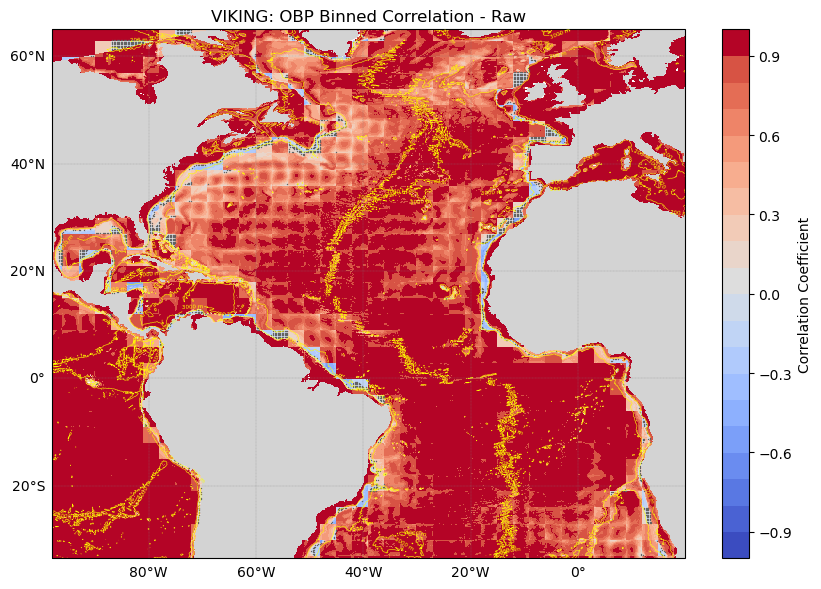

In [43]:
plot_corr_with_stippling(r_hr_c, sig_hr_c, title="VIKING: OBP Binned Correlation - Raw", stride=6)